In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold

In [2]:
df3 = pd.read_csv("../../data/merged_dataset_organized_45photic.csv")
print(df3.columns)

Index(['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'Cruise_ID', 'Cruz_Sta', 'Cast_ID',
       'Sta_ID', 'Distance', 'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line',
       'Bottom_D', 'Secchi', 'IntChl', 'IntC14', 'TimeZone', 'Visibility',
       'PHOTIC_ZONE'],
      dtype='object')


In [3]:
def calculate_photic_depth_at_threshold(group, threshold_pct, baseline=2):
    """Calculate depth where PAR drops to threshold_pct of 1, 2, 3, or 4m baseline."""
    group = group.sort_values('DEPTH').dropna(subset=['PAR'])
    
    depth_baseline = group[group['DEPTH'] == baseline]
    if len(depth_baseline) == 0 or len(group) < 2:
        return np.nan
    
    surface_par = depth_baseline['PAR'].iloc[0]
    if surface_par <= 0:
        return np.nan
    
    group = group[group['DEPTH'] >= baseline].copy()
    group['PAR_pct'] = (group['PAR'] / surface_par) * 100
    
    above = group[group['PAR_pct'] >= threshold_pct]
    below = group[group['PAR_pct'] < threshold_pct]
    
    if len(above) == 0 or len(below) == 0:
        return np.nan
    
    d_a, d_b = above['DEPTH'].iloc[-1], below['DEPTH'].iloc[0]
    p_a, p_b = above['PAR_pct'].iloc[-1], below['PAR_pct'].iloc[0]
    
    return d_a + (d_b - d_a) * (p_a - threshold_pct) / (p_a - p_b)

In [5]:
# 2m baseline
# Cross-validated threshold selection: 3% to 7% in 0.1% steps
thresholds_cv = [round(x * 0.1, 1) for x in range(30, 71)]

# Pre-compute photic depths for all thresholds and all casts
secchi_per_cast = df3.groupby('CAST_COUNT')['Secchi'].first()

photic_all = {}
for t in thresholds_cv:
    photic_all[t] = df3.groupby('CAST_COUNT').apply(
        lambda g, thresh=t: calculate_photic_depth_at_threshold(g, thresh), include_groups=False
    )

# Build a DataFrame: rows = casts, columns = thresholds + Secchi
cv_df = pd.DataFrame(photic_all)
cv_df['Secchi'] = secchi_per_cast

# Drop casts with no Secchi
cv_df = cv_df.dropna(subset=['Secchi'])

# 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cast_indices = np.arange(len(cv_df))

# Store per-fold correlations for each threshold
fold_correlations = {t: [] for t in thresholds_cv}

for train_idx, test_idx in kf.split(cast_indices):
    test_data = cv_df.iloc[test_idx]
    for t in thresholds_cv:
        valid = test_data[['Secchi', t]].dropna()
        if len(valid) >= 10:
            r = valid['Secchi'].corr(valid[t])
            fold_correlations[t].append(r)
        else:
            fold_correlations[t].append(np.nan)

# Compute mean and std of correlations across folds
mean_corr = {t: np.nanmean(fold_correlations[t]) for t in thresholds_cv}
std_corr = {t: np.nanstd(fold_correlations[t]) for t in thresholds_cv}

best_t_cv = max(mean_corr, key=mean_corr.get)

print("Cross-validated correlation (10-fold) between Secchi and photic depth (2m baseline):")
print(f"{'Threshold':>10} {'Mean r':>8} {'Std r':>8}")
print("-" * 28)
for t in thresholds_cv:
    print(f"{t:>9.1f}% {mean_corr[t]:>8.4f} {std_corr[t]:>8.4f}")
print(f"\nBest threshold: {best_t_cv}% (mean r = {mean_corr[best_t_cv]:.4f} +/- {std_corr[best_t_cv]:.4f})")

Cross-validated correlation (10-fold) between Secchi and photic depth (2m baseline):
 Threshold   Mean r    Std r
----------------------------
      3.0%   0.6826   0.1131
      3.1%   0.6790   0.1231
      3.2%   0.6774   0.1326
      3.3%   0.6729   0.1426
      3.4%   0.6714   0.1471
      3.5%   0.7016   0.1085
      3.6%   0.6698   0.1330
      3.7%   0.6729   0.1267
      3.8%   0.6758   0.1196
      3.9%   0.7064   0.0683
      4.0%   0.7089   0.0693
      4.1%   0.7086   0.0718
      4.2%   0.7083   0.0783
      4.3%   0.7071   0.0845
      4.4%   0.7031   0.0919
      4.5%   0.7286   0.0440
      4.6%   0.7247   0.0547
      4.7%   0.7337   0.0351
      4.8%   0.7285   0.0401
      4.9%   0.7264   0.0433
      5.0%   0.7151   0.0602
      5.1%   0.7255   0.0461
      5.2%   0.7101   0.0662
      5.3%   0.6905   0.1058
      5.4%   0.6733   0.1367
      5.5%   0.7084   0.0737
      5.6%   0.7046   0.0809
      5.7%   0.7028   0.0862
      5.8%   0.6749   0.1183
      5.9%   0.6

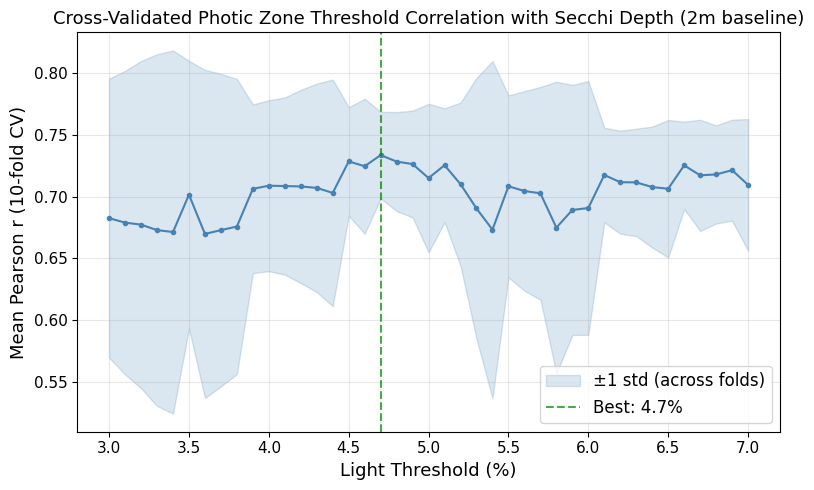

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

means = [mean_corr[t] for t in thresholds_cv]
stds = [std_corr[t] for t in thresholds_cv]

ax.plot(thresholds_cv, means, 'o-', color='steelblue', markersize=3)
ax.fill_between(thresholds_cv, 
                [m - s for m, s in zip(means, stds)],
                [m + s for m, s in zip(means, stds)],
                alpha=0.2, color='steelblue', label='±1 std (across folds)')
ax.axvline(x=best_t_cv, color='green', linestyle='--', alpha=0.7, label=f'Best: {best_t_cv}%')
ax.set_xlabel('Light Threshold (%)', fontsize=13)
ax.set_ylabel('Mean Pearson r (10-fold CV)', fontsize=13)
ax.set_title('Cross-Validated Photic Zone Threshold Correlation with Secchi Depth (2m baseline)', fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Cross-validated correlation (10-fold) between Secchi and photic depth (4.50% - 4.80%):
 Threshold   Mean r    Std r
----------------------------
     4.50%   0.7286   0.0440
     4.51%   0.7280   0.0445
     4.52%   0.7276   0.0453
     4.53%   0.7278   0.0459
     4.54%   0.7277   0.0472
     4.55%   0.7266   0.0487
     4.56%   0.7267   0.0495
     4.57%   0.7260   0.0520
     4.58%   0.7257   0.0528
     4.59%   0.7249   0.0540
     4.60%   0.7247   0.0547
     4.61%   0.7231   0.0554
     4.62%   0.7232   0.0565
     4.63%   0.7215   0.0573
     4.64%   0.7209   0.0584
     4.65%   0.7203   0.0592
     4.66%   0.7204   0.0603
     4.67%   0.7203   0.0614
     4.68%   0.7184   0.0617
     4.69%   0.7181   0.0626
     4.70%   0.7337   0.0351
     4.71%   0.7340   0.0352
     4.72%   0.7338   0.0353
     4.73%   0.7332   0.0355
     4.74%   0.7331   0.0357
     4.75%   0.7299   0.0381
     4.76%   0.7304   0.0381
     4.77%   0.7300   0.0385
     4.78%   0.7297   0.0389
     4.79%   0

/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_44997/2292848340.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data_fine, labels=[f'{t}%' for t in top_thresholds_fine])


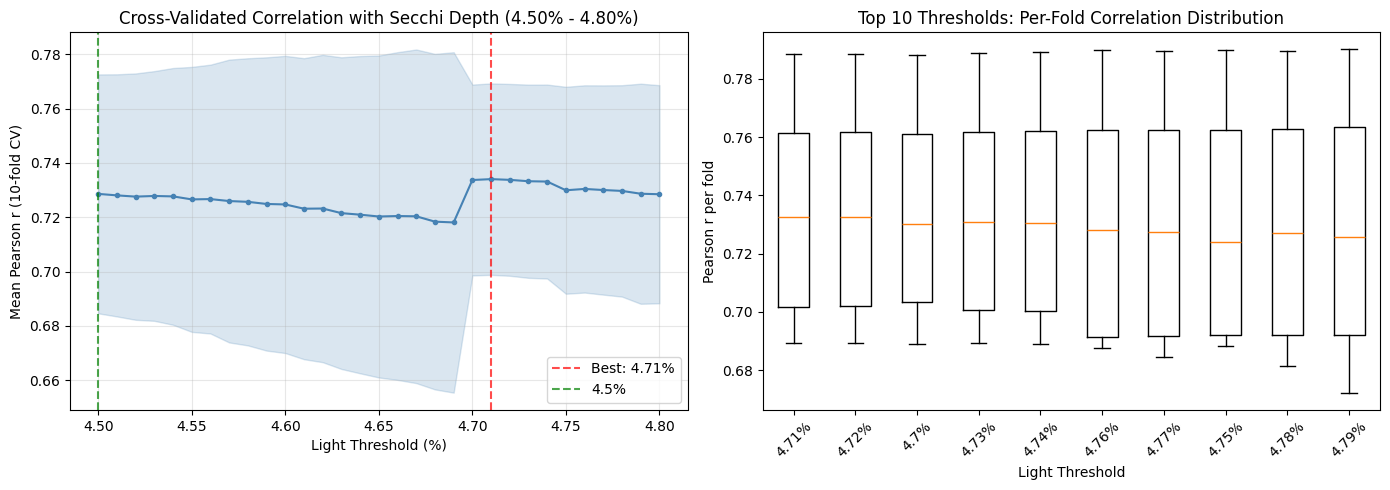

In [ ]:
# 2m baseline
# Cross-validated threshold selection (fine-grained): 4.5% to 4.8% in 0.01% steps
thresholds_cv_fine = [round(x * 0.01, 2) for x in range(450, 481)]

# Pre-compute photic depths for all thresholds and all casts
secchi_per_cast = df3.groupby('CAST_COUNT')['Secchi'].first()

photic_all_fine = {}
for t in thresholds_cv_fine:
    photic_all_fine[t] = df3.groupby('CAST_COUNT').apply(
        lambda g, thresh=t: calculate_photic_depth_at_threshold(g, thresh), include_groups=False
    )

# Build a DataFrame: rows = casts, columns = thresholds + Secchi
cv_df_fine = pd.DataFrame(photic_all_fine)
cv_df_fine['Secchi'] = secchi_per_cast

# Drop casts with no Secchi
cv_df_fine = cv_df_fine.dropna(subset=['Secchi'])

# 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cast_indices = np.arange(len(cv_df_fine))

# Store per-fold correlations for each threshold
fold_correlations_fine = {t: [] for t in thresholds_cv_fine}

for train_idx, test_idx in kf.split(cast_indices):
    test_data = cv_df_fine.iloc[test_idx]
    for t in thresholds_cv_fine:
        valid = test_data[['Secchi', t]].dropna()
        if len(valid) >= 10:
            r = valid['Secchi'].corr(valid[t])
            fold_correlations_fine[t].append(r)
        else:
            fold_correlations_fine[t].append(np.nan)

# Compute mean and std of correlations across folds
mean_corr_fine = {t: np.nanmean(fold_correlations_fine[t]) for t in thresholds_cv_fine}
std_corr_fine = {t: np.nanstd(fold_correlations_fine[t]) for t in thresholds_cv_fine}

# Display results
print("Cross-validated correlation (10-fold) between Secchi and photic depth (4.50% - 4.80%):")
print(f"{'Threshold':>10} {'Mean r':>8} {'Std r':>8}")
print("-" * 28)
for t in thresholds_cv_fine:
    print(f"{t:>9.2f}% {mean_corr_fine[t]:>8.4f} {std_corr_fine[t]:>8.4f}")

best_t_cv_fine = max(mean_corr_fine, key=mean_corr_fine.get)
print(f"\nBest threshold: {best_t_cv_fine}% (mean r = {mean_corr_fine[best_t_cv_fine]:.4f} +/- {std_corr_fine[best_t_cv_fine]:.4f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

means_fine = [mean_corr_fine[t] for t in thresholds_cv_fine]
stds_fine = [std_corr_fine[t] for t in thresholds_cv_fine]

axes[0].plot(thresholds_cv_fine, means_fine, 'o-', color='steelblue', markersize=3)
axes[0].fill_between(thresholds_cv_fine, 
                      [m - s for m, s in zip(means_fine, stds_fine)],
                      [m + s for m, s in zip(means_fine, stds_fine)],
                      alpha=0.2, color='steelblue')
axes[0].axvline(x=best_t_cv_fine, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_t_cv_fine}%')
axes[0].axvline(x=4.5, color='green', linestyle='--', alpha=0.7, label='4.5%')
axes[0].set_xlabel('Light Threshold (%)')
axes[0].set_ylabel('Mean Pearson r (10-fold CV)')
axes[0].set_title('Cross-Validated Correlation (2m) with Secchi Depth (4.50% - 4.80%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot of per-fold correlations for top candidates
top_thresholds_fine = sorted(mean_corr_fine, key=mean_corr_fine.get, reverse=True)[:10]
box_data_fine = [fold_correlations_fine[t] for t in top_thresholds_fine]
axes[1].boxplot(box_data_fine, labels=[f'{t}%' for t in top_thresholds_fine])
axes[1].set_xlabel('Light Threshold')
axes[1].set_ylabel('Pearson r per fold')
axes[1].set_title('Top 10 Thresholds: Per-Fold Correlation Distribution')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Choosing the photic depth threshold of 4.7% seems like the most logical option since 4.71% increases R only marginally. 

We find the optimal (correlation based) photic zone light thresholds for 1, 3, and 4 m baselines as well to increase sample size:


Computing photic depths for 1m baseline...
Cross-validated correlation (10-fold) — Secchi vs photic depth (1m baseline):
 Threshold   Mean r    Std r
----------------------------
      1.0%   0.5936   0.2335
      1.5%   0.6737   0.1472
      2.0%   0.7007   0.0949
      2.5%   0.6906   0.1496
      3.0%   0.6723   0.1906
      3.5%   0.6983   0.1404
      4.0%   0.7195   0.0795
      4.5%   0.7201   0.0746
      5.0%   0.6532   0.1883
      5.5%   0.7042   0.0783
      6.0%   0.7014   0.0767
      6.5%   0.6897   0.0821
      7.0%   0.6652   0.0844

Best threshold: 4.5% (mean r = 0.7201 ± 0.0746)  [n=2774 casts]

Computing photic depths for 3m baseline...
Cross-validated correlation (10-fold) — Secchi vs photic depth (3m baseline):
 Threshold   Mean r    Std r
----------------------------
      1.0%   0.5623   0.0943
      1.5%   0.6365   0.1240
      2.0%   0.6206   0.1319
      2.5%   0.6731   0.0996
      3.0%   0.6928   0.0821
      3.5%   0.6716   0.1262
      4.0%   0.6732   0.

/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_65230/871231778.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=[f'{t}%' for t in top_t], patch_artist=True)
/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_65230/871231778.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=[f'{t}%' for t in top_t], patch_artist=True)
/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_65230/871231778.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=[f'{t}%' for t in top_t], patch_artist=True)


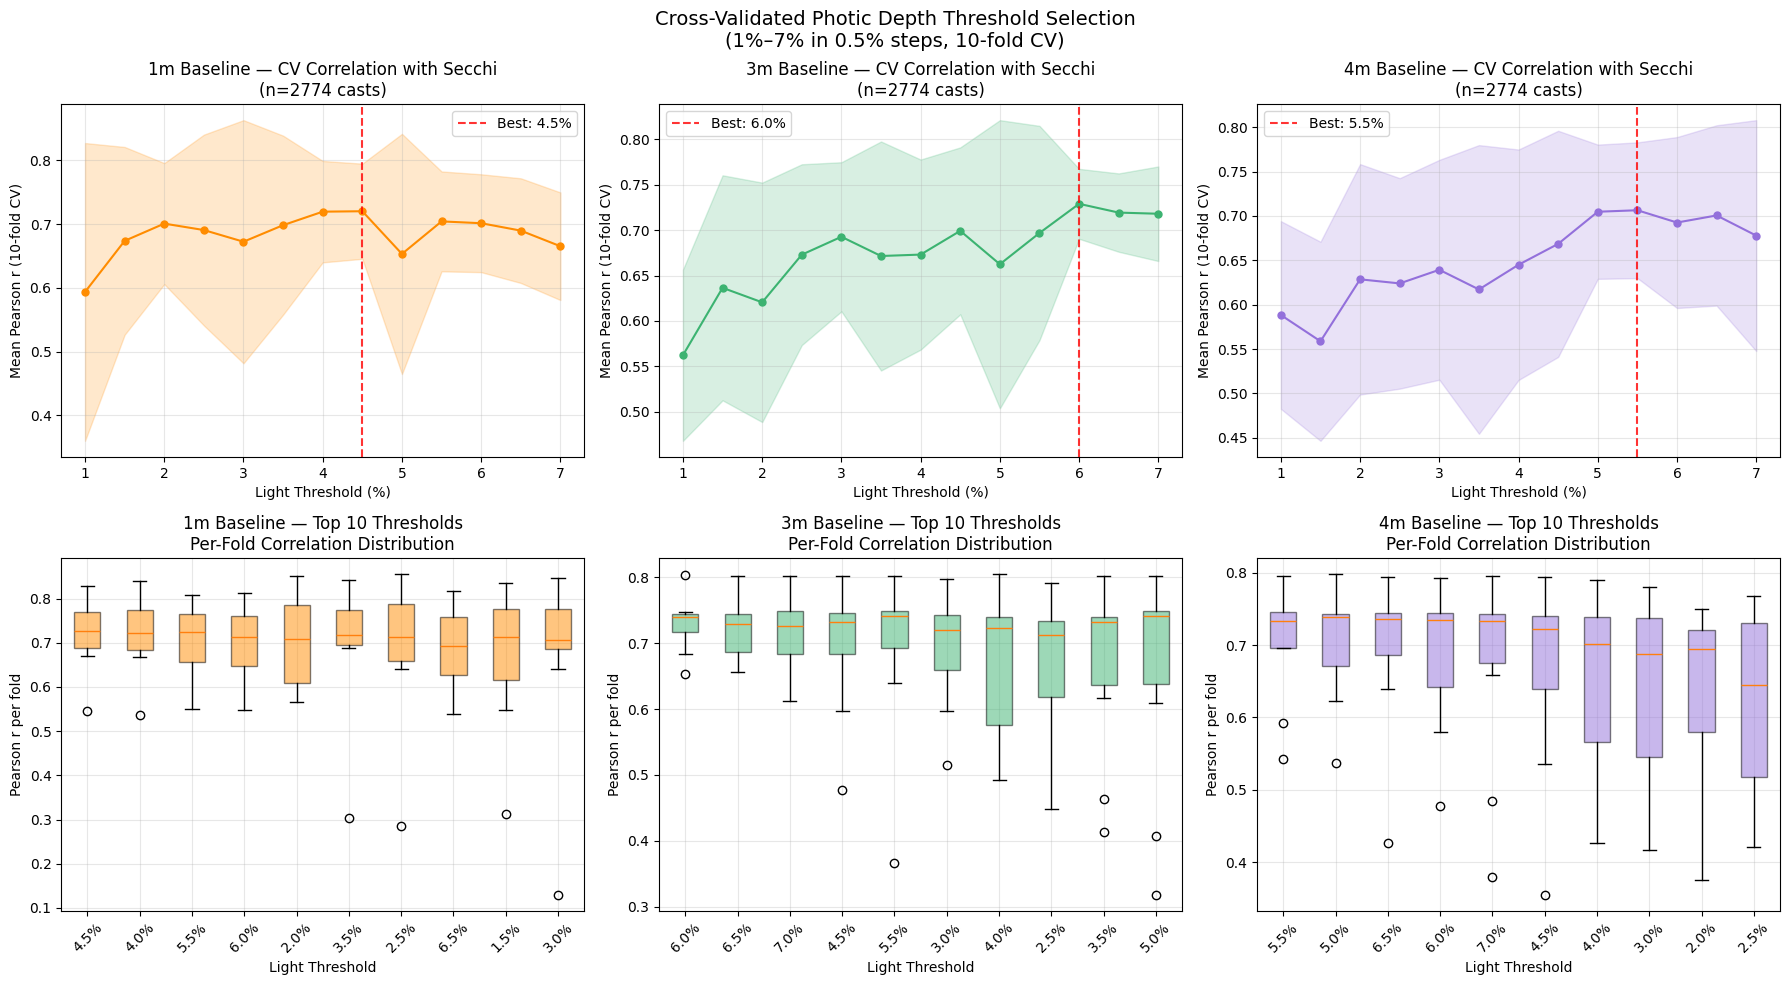


Summary of best thresholds across baselines:
Baseline  Best threshold   Mean r    Std r   N casts
----------------------------------------------------
     1m            4.5%    0.7201    0.0746       2774
     3m            6.0%    0.7291    0.0385       2774
     4m            5.5%    0.7064    0.0764       2774


In [4]:

# Cross-validation for 1m, 3m, and 4m baselines
# Thresholds: 1% to 7% in 0.5% steps
thresholds_alt = [round(x * 0.5, 1) for x in range(2, 15)]  # 1.0, 1.5, ..., 7.0

baselines = [1, 3, 4]
colors = {1: 'darkorange', 3: 'mediumseagreen', 4: 'mediumpurple'}

secchi_per_cast = df3.groupby('CAST_COUNT')['Secchi'].first()

results = {}  # results[baseline] = {'mean_corr': ..., 'std_corr': ..., 'fold_correlations': ...}

for baseline in baselines:
    print(f"\nComputing photic depths for {baseline}m baseline...")
    photic_all = {}
    for t in thresholds_alt:
        photic_all[t] = df3.groupby('CAST_COUNT').apply(
            lambda g, thresh=t, b=baseline: calculate_photic_depth_at_threshold(g, thresh, baseline=b),
            include_groups=False
        )

    cv_df = pd.DataFrame(photic_all)
    cv_df['Secchi'] = secchi_per_cast
    cv_df = cv_df.dropna(subset=['Secchi'])

    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    cast_indices = np.arange(len(cv_df))

    fold_correlations = {t: [] for t in thresholds_alt}
    for train_idx, test_idx in kf.split(cast_indices):
        test_data = cv_df.iloc[test_idx]
        for t in thresholds_alt:
            valid = test_data[['Secchi', t]].dropna()
            if len(valid) >= 10:
                r = valid['Secchi'].corr(valid[t])
                fold_correlations[t].append(r)
            else:
                fold_correlations[t].append(np.nan)

    mean_corr = {t: np.nanmean(fold_correlations[t]) for t in thresholds_alt}
    std_corr  = {t: np.nanstd(fold_correlations[t])  for t in thresholds_alt}
    best_t    = max(mean_corr, key=mean_corr.get)

    results[baseline] = {
        'mean_corr': mean_corr,
        'std_corr': std_corr,
        'fold_correlations': fold_correlations,
        'best_t': best_t,
        'n_casts': len(cv_df),
    }

    print(f"Cross-validated correlation (10-fold) — Secchi vs photic depth ({baseline}m baseline):")
    print(f"{'Threshold':>10} {'Mean r':>8} {'Std r':>8}")
    print("-" * 28)
    for t in thresholds_alt:
        print(f"{t:>9.1f}% {mean_corr[t]:>8.4f} {std_corr[t]:>8.4f}")
    print(f"\nBest threshold: {best_t}% (mean r = {mean_corr[best_t]:.4f} ± {std_corr[best_t]:.4f})  [n={len(cv_df)} casts]")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, baseline in enumerate(baselines):
    res   = results[baseline]
    means = [res['mean_corr'][t] for t in thresholds_alt]
    stds  = [res['std_corr'][t]  for t in thresholds_alt]
    best  = res['best_t']
    color = colors[baseline]

    # Row 0: mean r curve with ±1 std band
    ax = axes[0, col]
    ax.plot(thresholds_alt, means, 'o-', color=color, markersize=5)
    ax.fill_between(thresholds_alt,
                    [m - s for m, s in zip(means, stds)],
                    [m + s for m, s in zip(means, stds)],
                    alpha=0.2, color=color)
    ax.axvline(x=best, color='red', linestyle='--', alpha=0.8, label=f'Best: {best}%')
    ax.set_xlabel('Light Threshold (%)')
    ax.set_ylabel('Mean Pearson r (10-fold CV)')
    ax.set_title(f'{baseline}m Baseline — CV Correlation with Secchi\n(n={res["n_casts"]} casts)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Row 1: box plot of top-10 thresholds by mean r
    ax = axes[1, col]
    top_t    = sorted(res['mean_corr'], key=res['mean_corr'].get, reverse=True)[:10]
    box_data = [res['fold_correlations'][t] for t in top_t]
    bp = ax.boxplot(box_data, labels=[f'{t}%' for t in top_t], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    ax.set_xlabel('Light Threshold')
    ax.set_ylabel('Pearson r per fold')
    ax.set_title(f'{baseline}m Baseline — Top 10 Thresholds\nPer-Fold Correlation Distribution')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.suptitle('Cross-Validated Photic Depth Threshold Selection\n(1%–7% in 0.5% steps, 10-fold CV)', fontsize=14)
plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────────
print("\nSummary of best thresholds across baselines:")
print(f"{'Baseline':>8} {'Best threshold':>15} {'Mean r':>8} {'Std r':>8} {'N casts':>9}")
print("-" * 52)
for baseline in baselines:
    res = results[baseline]
    bt  = res['best_t']
    print(f"{baseline:>6}m  {bt:>13.1f}%  {res['mean_corr'][bt]:>8.4f}  {res['std_corr'][bt]:>8.4f}  {res['n_casts']:>9}")


Cross-validated correlation (10-fold) — Secchi vs photic depth (1m baseline, 4.00%–5.00%):
 Threshold   Mean r    Std r
----------------------------
     4.00%   0.7195   0.0795
     4.05%   0.7191   0.0781
     4.10%   0.7191   0.0787
     4.15%   0.7196   0.0788
     4.20%   0.7188   0.0802
     4.25%   0.7221   0.0783
     4.30%   0.7113   0.0869
     4.35%   0.7177   0.0780
     4.40%   0.7166   0.0774
     4.45%   0.7179   0.0744
     4.50%   0.7201   0.0746
     4.55%   0.7157   0.0763
     4.60%   0.7210   0.0745
     4.65%   0.7196   0.0789
     4.70%   0.7217   0.0739
     4.75%   0.7174   0.0778
     4.80%   0.7116   0.0848
     4.85%   0.7194   0.0764
     4.90%   0.7109   0.0855
     4.95%   0.7143   0.0760
     5.00%   0.6532   0.1883

Best threshold: 4.25% (mean r = 0.7221 ± 0.0783)


/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_65230/3580500055.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data_fine, labels=[f'{t}%' for t in top_t_fine], patch_artist=True)


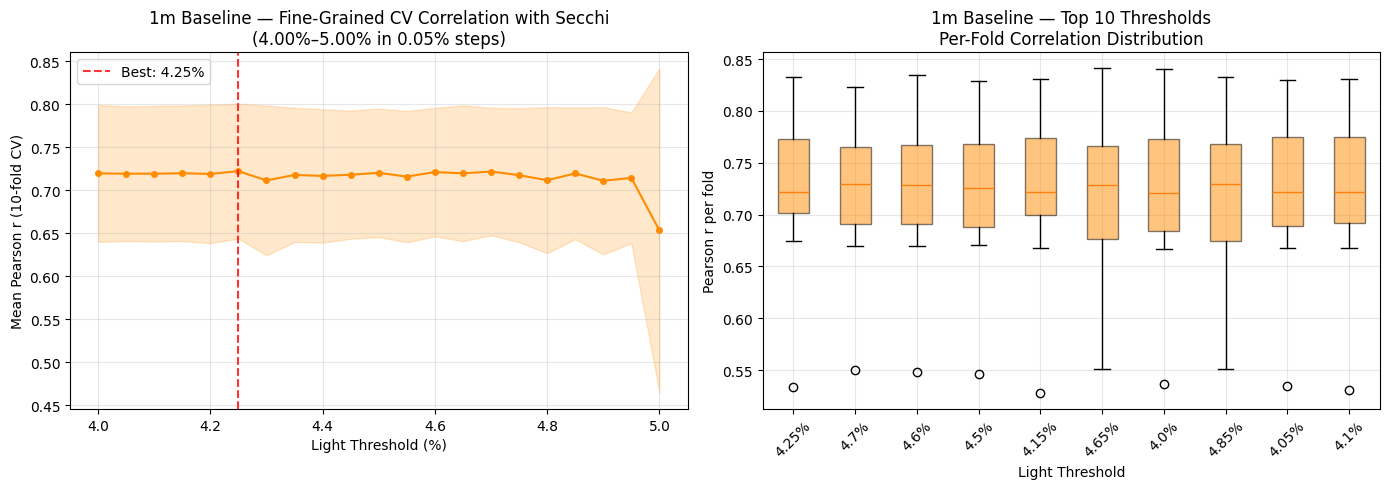

In [5]:

# Fine-grained CV for 1m baseline: 4% to 5% in 0.05% steps
thresholds_1m_fine = [round(x * 0.05, 2) for x in range(80, 101)]  # 4.00, 4.05, ..., 5.00

secchi_per_cast = df3.groupby('CAST_COUNT')['Secchi'].first()

photic_1m_fine = {}
for t in thresholds_1m_fine:
    photic_1m_fine[t] = df3.groupby('CAST_COUNT').apply(
        lambda g, thresh=t: calculate_photic_depth_at_threshold(g, thresh, baseline=1),
        include_groups=False
    )

cv_df_1m_fine = pd.DataFrame(photic_1m_fine)
cv_df_1m_fine['Secchi'] = secchi_per_cast
cv_df_1m_fine = cv_df_1m_fine.dropna(subset=['Secchi'])

kf = KFold(n_splits=10, shuffle=True, random_state=42)
fold_correlations_1m_fine = {t: [] for t in thresholds_1m_fine}

for train_idx, test_idx in kf.split(np.arange(len(cv_df_1m_fine))):
    test_data = cv_df_1m_fine.iloc[test_idx]
    for t in thresholds_1m_fine:
        valid = test_data[['Secchi', t]].dropna()
        if len(valid) >= 10:
            fold_correlations_1m_fine[t].append(valid['Secchi'].corr(valid[t]))
        else:
            fold_correlations_1m_fine[t].append(np.nan)

mean_corr_1m_fine = {t: np.nanmean(fold_correlations_1m_fine[t]) for t in thresholds_1m_fine}
std_corr_1m_fine  = {t: np.nanstd(fold_correlations_1m_fine[t])  for t in thresholds_1m_fine}
best_t_1m_fine    = max(mean_corr_1m_fine, key=mean_corr_1m_fine.get)

print("Cross-validated correlation (10-fold) — Secchi vs photic depth (1m baseline, 4.00%–5.00%):")
print(f"{'Threshold':>10} {'Mean r':>8} {'Std r':>8}")
print("-" * 28)
for t in thresholds_1m_fine:
    print(f"{t:>9.2f}% {mean_corr_1m_fine[t]:>8.4f} {std_corr_1m_fine[t]:>8.4f}")
print(f"\nBest threshold: {best_t_1m_fine}% (mean r = {mean_corr_1m_fine[best_t_1m_fine]:.4f} ± {std_corr_1m_fine[best_t_1m_fine]:.4f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

means_f = [mean_corr_1m_fine[t] for t in thresholds_1m_fine]
stds_f  = [std_corr_1m_fine[t]  for t in thresholds_1m_fine]

axes[0].plot(thresholds_1m_fine, means_f, 'o-', color='darkorange', markersize=4)
axes[0].fill_between(thresholds_1m_fine,
                     [m - s for m, s in zip(means_f, stds_f)],
                     [m + s for m, s in zip(means_f, stds_f)],
                     alpha=0.2, color='darkorange')
axes[0].axvline(x=best_t_1m_fine, color='red', linestyle='--', alpha=0.8, label=f'Best: {best_t_1m_fine}%')
axes[0].set_xlabel('Light Threshold (%)')
axes[0].set_ylabel('Mean Pearson r (10-fold CV)')
axes[0].set_title('1m Baseline — Fine-Grained CV Correlation with Secchi\n(4.00%–5.00% in 0.05% steps)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

top_t_fine = sorted(mean_corr_1m_fine, key=mean_corr_1m_fine.get, reverse=True)[:10]
box_data_fine = [fold_correlations_1m_fine[t] for t in top_t_fine]
bp = axes[1].boxplot(box_data_fine, labels=[f'{t}%' for t in top_t_fine], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('darkorange')
    patch.set_alpha(0.5)
axes[1].set_xlabel('Light Threshold')
axes[1].set_ylabel('Pearson r per fold')
axes[1].set_title('1m Baseline — Top 10 Thresholds\nPer-Fold Correlation Distribution')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Cross-validated correlation (10-fold) — Secchi vs photic depth (3m baseline, 5.50%–6.50%):
 Threshold   Mean r    Std r
----------------------------
     5.50%   0.6969   0.1181
     5.55%   0.7279   0.0432
     5.60%   0.7294   0.0421
     5.65%   0.7301   0.0414
     5.70%   0.7305   0.0407
     5.75%   0.7305   0.0400
     5.80%   0.7299   0.0396
     5.85%   0.7298   0.0398
     5.90%   0.7297   0.0394
     5.95%   0.7297   0.0396
     6.00%   0.7291   0.0385
     6.05%   0.7282   0.0389
     6.10%   0.7290   0.0397
     6.15%   0.7275   0.0396
     6.20%   0.7270   0.0406
     6.25%   0.7259   0.0404
     6.30%   0.7247   0.0400
     6.35%   0.7251   0.0412
     6.40%   0.7222   0.0404
     6.45%   0.7199   0.0413
     6.50%   0.7194   0.0432

Best threshold: 5.7% (mean r = 0.7305 ± 0.0407)


/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_65230/2349037356.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data_3m_fine, labels=[f'{t}%' for t in top_t_3m_fine], patch_artist=True)


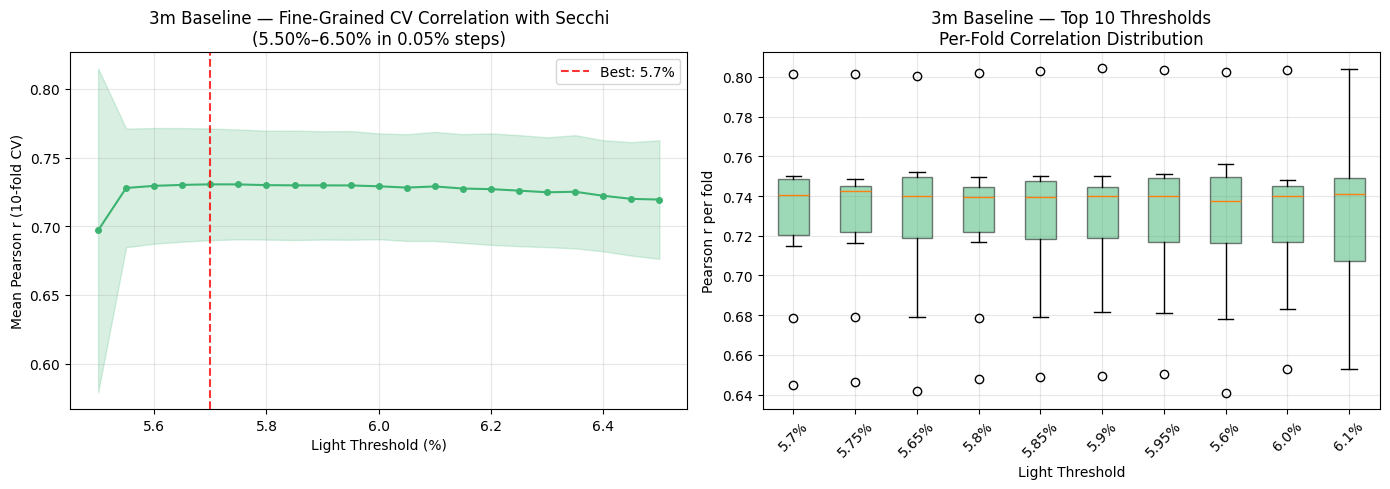

In [6]:

# Fine-grained CV for 3m baseline: 5.5% to 6.5% in 0.05% steps
thresholds_3m_fine = [round(x * 0.05, 2) for x in range(110, 131)]  # 5.50, 5.55, ..., 6.50

secchi_per_cast = df3.groupby('CAST_COUNT')['Secchi'].first()

photic_3m_fine = {}
for t in thresholds_3m_fine:
    photic_3m_fine[t] = df3.groupby('CAST_COUNT').apply(
        lambda g, thresh=t: calculate_photic_depth_at_threshold(g, thresh, baseline=3),
        include_groups=False
    )

cv_df_3m_fine = pd.DataFrame(photic_3m_fine)
cv_df_3m_fine['Secchi'] = secchi_per_cast
cv_df_3m_fine = cv_df_3m_fine.dropna(subset=['Secchi'])

kf = KFold(n_splits=10, shuffle=True, random_state=42)
fold_correlations_3m_fine = {t: [] for t in thresholds_3m_fine}

for train_idx, test_idx in kf.split(np.arange(len(cv_df_3m_fine))):
    test_data = cv_df_3m_fine.iloc[test_idx]
    for t in thresholds_3m_fine:
        valid = test_data[['Secchi', t]].dropna()
        if len(valid) >= 10:
            fold_correlations_3m_fine[t].append(valid['Secchi'].corr(valid[t]))
        else:
            fold_correlations_3m_fine[t].append(np.nan)

mean_corr_3m_fine = {t: np.nanmean(fold_correlations_3m_fine[t]) for t in thresholds_3m_fine}
std_corr_3m_fine  = {t: np.nanstd(fold_correlations_3m_fine[t])  for t in thresholds_3m_fine}
best_t_3m_fine    = max(mean_corr_3m_fine, key=mean_corr_3m_fine.get)

print("Cross-validated correlation (10-fold) — Secchi vs photic depth (3m baseline, 5.50%–6.50%):")
print(f"{'Threshold':>10} {'Mean r':>8} {'Std r':>8}")
print("-" * 28)
for t in thresholds_3m_fine:
    print(f"{t:>9.2f}% {mean_corr_3m_fine[t]:>8.4f} {std_corr_3m_fine[t]:>8.4f}")
print(f"\nBest threshold: {best_t_3m_fine}% (mean r = {mean_corr_3m_fine[best_t_3m_fine]:.4f} ± {std_corr_3m_fine[best_t_3m_fine]:.4f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

means_3f = [mean_corr_3m_fine[t] for t in thresholds_3m_fine]
stds_3f  = [std_corr_3m_fine[t]  for t in thresholds_3m_fine]

axes[0].plot(thresholds_3m_fine, means_3f, 'o-', color='mediumseagreen', markersize=4)
axes[0].fill_between(thresholds_3m_fine,
                     [m - s for m, s in zip(means_3f, stds_3f)],
                     [m + s for m, s in zip(means_3f, stds_3f)],
                     alpha=0.2, color='mediumseagreen')
axes[0].axvline(x=best_t_3m_fine, color='red', linestyle='--', alpha=0.8, label=f'Best: {best_t_3m_fine}%')
axes[0].set_xlabel('Light Threshold (%)')
axes[0].set_ylabel('Mean Pearson r (10-fold CV)')
axes[0].set_title('3m Baseline — Fine-Grained CV Correlation with Secchi\n(5.50%–6.50% in 0.05% steps)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

top_t_3m_fine = sorted(mean_corr_3m_fine, key=mean_corr_3m_fine.get, reverse=True)[:10]
box_data_3m_fine = [fold_correlations_3m_fine[t] for t in top_t_3m_fine]
bp = axes[1].boxplot(box_data_3m_fine, labels=[f'{t}%' for t in top_t_3m_fine], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('mediumseagreen')
    patch.set_alpha(0.5)
axes[1].set_xlabel('Light Threshold')
axes[1].set_ylabel('Pearson r per fold')
axes[1].set_title('3m Baseline — Top 10 Thresholds\nPer-Fold Correlation Distribution')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Cross-validated correlation (10-fold) — Secchi vs photic depth (4m baseline, 5.00%–6.00%):
 Threshold   Mean r    Std r
----------------------------
     5.00%   0.7047   0.0756
     5.05%   0.7079   0.0717
     5.10%   0.7085   0.0721
     5.15%   0.6743   0.1201
     5.20%   0.6723   0.1262
     5.25%   0.6808   0.1043
     5.30%   0.6886   0.0916
     5.35%   0.6946   0.0817
     5.40%   0.6998   0.0784
     5.45%   0.7037   0.0762
     5.50%   0.7064   0.0764
     5.55%   0.7079   0.0772
     5.60%   0.7081   0.0779
     5.65%   0.7068   0.0786
     5.70%   0.7069   0.0795
     5.75%   0.7052   0.0814
     5.80%   0.6743   0.1261
     5.85%   0.6965   0.0868
     5.90%   0.6934   0.0920
     5.95%   0.6964   0.0919
     6.00%   0.6925   0.0963

Best threshold: 5.1% (mean r = 0.7085 ± 0.0721)


/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_65230/296318589.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data_4m_fine, labels=[f'{t}%' for t in top_t_4m_fine], patch_artist=True)


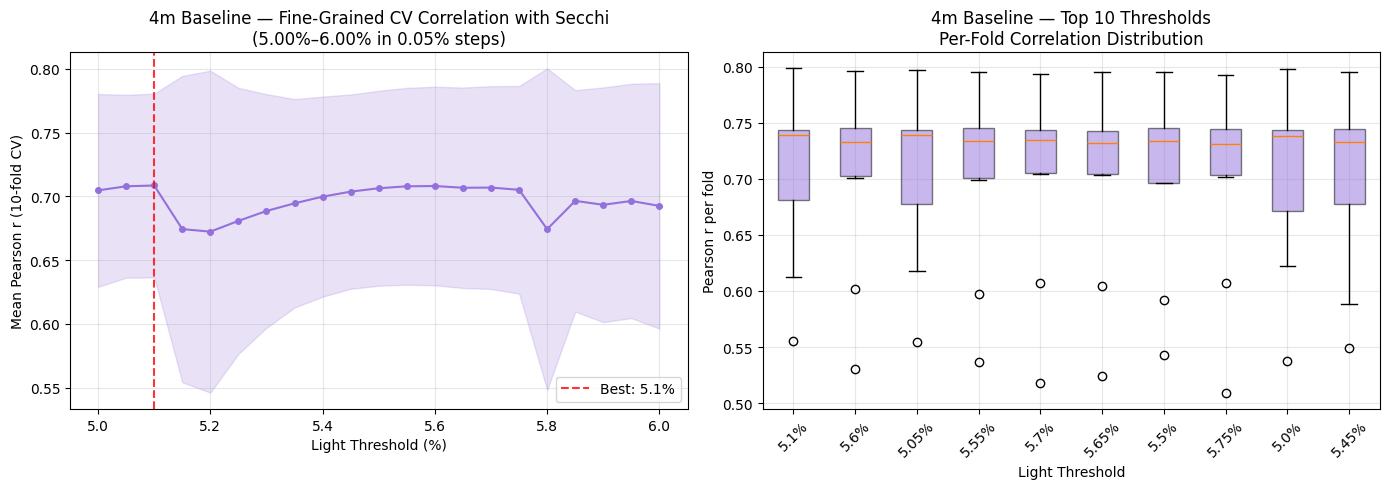

In [7]:

# Fine-grained CV for 4m baseline: 5.0% to 6.0% in 0.05% steps
thresholds_4m_fine = [round(x * 0.05, 2) for x in range(100, 121)]  # 5.00, 5.05, ..., 6.00

secchi_per_cast = df3.groupby('CAST_COUNT')['Secchi'].first()

photic_4m_fine = {}
for t in thresholds_4m_fine:
    photic_4m_fine[t] = df3.groupby('CAST_COUNT').apply(
        lambda g, thresh=t: calculate_photic_depth_at_threshold(g, thresh, baseline=4),
        include_groups=False
    )

cv_df_4m_fine = pd.DataFrame(photic_4m_fine)
cv_df_4m_fine['Secchi'] = secchi_per_cast
cv_df_4m_fine = cv_df_4m_fine.dropna(subset=['Secchi'])

kf = KFold(n_splits=10, shuffle=True, random_state=42)
fold_correlations_4m_fine = {t: [] for t in thresholds_4m_fine}

for train_idx, test_idx in kf.split(np.arange(len(cv_df_4m_fine))):
    test_data = cv_df_4m_fine.iloc[test_idx]
    for t in thresholds_4m_fine:
        valid = test_data[['Secchi', t]].dropna()
        if len(valid) >= 10:
            fold_correlations_4m_fine[t].append(valid['Secchi'].corr(valid[t]))
        else:
            fold_correlations_4m_fine[t].append(np.nan)

mean_corr_4m_fine = {t: np.nanmean(fold_correlations_4m_fine[t]) for t in thresholds_4m_fine}
std_corr_4m_fine  = {t: np.nanstd(fold_correlations_4m_fine[t])  for t in thresholds_4m_fine}
best_t_4m_fine    = max(mean_corr_4m_fine, key=mean_corr_4m_fine.get)

print("Cross-validated correlation (10-fold) — Secchi vs photic depth (4m baseline, 5.00%–6.00%):")
print(f"{'Threshold':>10} {'Mean r':>8} {'Std r':>8}")
print("-" * 28)
for t in thresholds_4m_fine:
    print(f"{t:>9.2f}% {mean_corr_4m_fine[t]:>8.4f} {std_corr_4m_fine[t]:>8.4f}")
print(f"\nBest threshold: {best_t_4m_fine}% (mean r = {mean_corr_4m_fine[best_t_4m_fine]:.4f} ± {std_corr_4m_fine[best_t_4m_fine]:.4f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

means_4f = [mean_corr_4m_fine[t] for t in thresholds_4m_fine]
stds_4f  = [std_corr_4m_fine[t]  for t in thresholds_4m_fine]

axes[0].plot(thresholds_4m_fine, means_4f, 'o-', color='mediumpurple', markersize=4)
axes[0].fill_between(thresholds_4m_fine,
                     [m - s for m, s in zip(means_4f, stds_4f)],
                     [m + s for m, s in zip(means_4f, stds_4f)],
                     alpha=0.2, color='mediumpurple')
axes[0].axvline(x=best_t_4m_fine, color='red', linestyle='--', alpha=0.8, label=f'Best: {best_t_4m_fine}%')
axes[0].set_xlabel('Light Threshold (%)')
axes[0].set_ylabel('Mean Pearson r (10-fold CV)')
axes[0].set_title('4m Baseline — Fine-Grained CV Correlation with Secchi\n(5.00%–6.00% in 0.05% steps)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

top_t_4m_fine = sorted(mean_corr_4m_fine, key=mean_corr_4m_fine.get, reverse=True)[:10]
box_data_4m_fine = [fold_correlations_4m_fine[t] for t in top_t_4m_fine]
bp = axes[1].boxplot(box_data_4m_fine, labels=[f'{t}%' for t in top_t_4m_fine], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('mediumpurple')
    patch.set_alpha(0.5)
axes[1].set_xlabel('Light Threshold')
axes[1].set_ylabel('Pearson r per fold')
axes[1].set_title('4m Baseline — Top 10 Thresholds\nPer-Fold Correlation Distribution')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Best photic zone light thresholds for 1, 2, 3, and 4m baseline depths:
- 1m: 4.25%
- 2m: 4.7%
- 3m: 5.7%
- 4m: 5.1%

In [8]:
min_depths = df3.groupby('CAST_COUNT')['DEPTH'].min()
print(f"\nMinimum depth distribution across casts:")
print(min_depths.value_counts().sort_index().head(10))


Minimum depth distribution across casts:
DEPTH
1.0      741
2.0     1547
3.0      422
4.0       47
5.0        5
6.0        1
7.0        1
8.0        1
11.0       1
12.0       4
Name: count, dtype: int64


In [9]:
# Recompute PHOTIC_ZONE (bool) and add baseline_depth column
# Baseline selection: cast min depth → threshold
baseline_thresholds = {1: 4.25, 2: 4.7, 3: 5.7, 4: 5.1}

cast_min_depth = df3.groupby('CAST_COUNT')['DEPTH'].min()

# Map each cast to its baseline (int), or NaN if min depth not in {1,2,3,4}
def assign_baseline(min_d):
    md = int(min_d) if min_d == int(min_d) else None
    return md if md in baseline_thresholds else pd.NA

cast_baseline = cast_min_depth.apply(assign_baseline)

# Reset both columns
df3['PHOTIC_ZONE']    = False
df3['baseline_depth'] = pd.NA

for cast_id, group in df3.groupby('CAST_COUNT'):
    baseline = cast_baseline.get(cast_id, pd.NA)
    if pd.isna(baseline):
        continue
    baseline = int(baseline)
    threshold = baseline_thresholds[baseline]

    # Mark baseline_depth for every row in this cast
    df3.loc[group.index, 'baseline_depth'] = baseline

    # Calculate interpolated photic depth
    photic_depth = calculate_photic_depth_at_threshold(group, threshold, baseline=baseline)
    if pd.isna(photic_depth):
        continue

    # Find the row whose DEPTH is closest to the interpolated photic depth
    sub = group[group['DEPTH'] >= baseline].dropna(subset=['DEPTH'])
    if sub.empty:
        continue
    closest_idx = (sub['DEPTH'] - photic_depth).abs().idxmin()
    df3.loc[closest_idx, 'PHOTIC_ZONE'] = True

df3['baseline_depth'] = df3['baseline_depth'].astype('Int64')

# Sanity check
n_photic = df3['PHOTIC_ZONE'].sum()
n_baseline = df3['baseline_depth'].notna().groupby(df3['CAST_COUNT']).first().sum()
print(f"Photic zone rows marked True: {n_photic}")
print(f"Casts with a valid baseline:  {n_baseline}")
print()
print("baseline_depth value counts:")
print(df3['baseline_depth'].value_counts().sort_index())
print()
print("Sample rows:")
print(df3[df3['PHOTIC_ZONE'] == True][['CAST_COUNT', 'DEPTH', 'PAR', 'PHOTIC_ZONE', 'baseline_depth']].head(10))


Photic zone rows marked True: 2388
Casts with a valid baseline:  2757

baseline_depth value counts:
baseline_depth
1    312422
2    705623
3    206906
4     24164
Name: count, dtype: Int64

Sample rows:
      CAST_COUNT  DEPTH    PAR  PHOTIC_ZONE  baseline_depth
26         27453   28.0  25.99         True               2
98         27458   46.0  38.63         True               2
1153       27462   57.0  16.34         True               3
1678       27463   58.0  23.12         True               2
2221       27466   77.0  12.61         True               2
2764       27467   90.0   8.61         True               3
3255       27470   57.0   6.64         True               2
3761       27474   37.0  14.09         True               2
4295       27479   44.0   8.66         True               1
4797       27480   21.0  27.39         True               1


In [10]:
df3.to_parquet("../Data/Parquet/final_data.parquet", index=False)
print("Saved to ../Data/Parquet/final_data.parquet")


Saved to ../Data/Parquet/final_data.parquet
